---
---
---

# Banned But Not Forgotten — Remaining Tasks & Starter Code

## Quick Fixes (Before Anything Else)

Two files were missing from the last pipeline run. Re-run the pipeline once these are added:

1.  **`election_results.xlsx`** — extract from `2024_Presidential_Election_Results.zip` and place in the pipeline folder. Without this, all political lean data shows `?`.
2.  **`full_book_details.csv`** — Violet's expanded Goodreads file. Without this, the genre supplement doesn't generate (category coverage drops from 81% → 80%).

Then re-run:

``` bash
python analysis_pipeline.py


All outputs in `outputs/` will update with correct political data.

------------------------------------------------------------------------

## What the Data Now Shows (Updated Findings)

With 3,463 Google Trends titles (up from 634) and 7,293 Goodreads books (up from 256):

| Finding | Status | Evidence |
|------------------------|----------------------|---------------------------|
| Bans on average REDUCE search interest | **Now significant** (p=0.017) | Mean change = -6.7%, Cohen's d = -0.05 |
| Streisand Effect depends on pre-ban popularity | **Highly significant** (p \< 0.000001) | η² = 0.116 (large), 8 post-hoc pairs significant |
| Content category does NOT matter | Confirmed null | KW p=0.95, χ² p=0.97 — spike rates \~48% for all categories |
| Ban frequency does NOT predict spikes | **Flipped to null** | ρ=0.007, p=0.73 (was significant with smaller sample) |

------------------------------------------------------------------------

## Violet — Data Visualization & Analysis

### Deliverables

1.  Streisand Effect by popularity tier (THE key chart)
2.  Before/after scatter plot
3.  Top 10 Streisand / Top 10 Suppressed bar chart
4.  Challenge reason distribution
5.  Goodreads engagement vs banning scatter

### Source Files

-   `outputs/google_trends_cleaned.csv` — 2,440 rows with before/after search data
-   `outputs/goodreads_cleaned.csv` — 7,293 rows with ratings and engagement
-   `outputs/title_categories.csv` — 8,360 rows with challenge reasons
-   `outputs/categories_x_google_trends.csv` — merged categories + trends

### Setup

bash
pip install pandas matplotlib seaborn numpy


### Tutorial Videos

-   Matplotlib basics: <https://www.youtube.com/watch?v=UO98lJQ3QGI>
-   Seaborn statistical visualizations: <https://www.youtube.com/watch?v=6GUZXDef2U0>
-   Box plots and grouped bars in seaborn: <https://www.youtube.com/watch?v=IIwRMsOqc20>
-   Customizing matplotlib for publication: <https://www.youtube.com/watch?v=DAQNHzOcO5A>

### VIZ 1: Streisand Effect by Popularity Tier (most important chart)

This is the headline visualization. Show that moderately popular books spike, low-interest books get suppressed, and very popular books barely move.

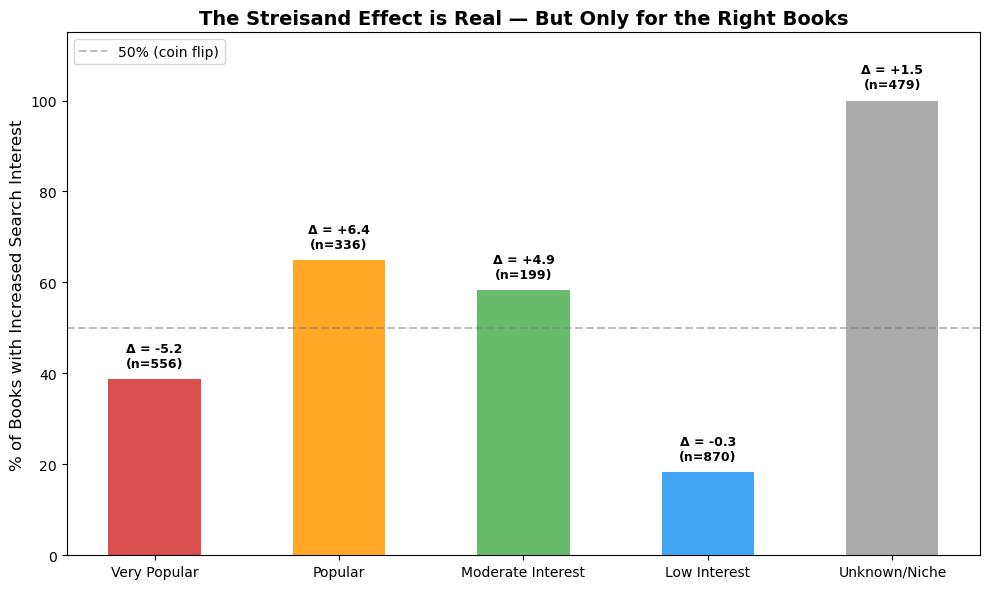

/var/folders/bp/n09_8ybn2t3bm81y47gj3vg00000gn/T/ipykernel_18512/953426173.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gt, x='pre_ban_popularity', y='spike_magnitude',


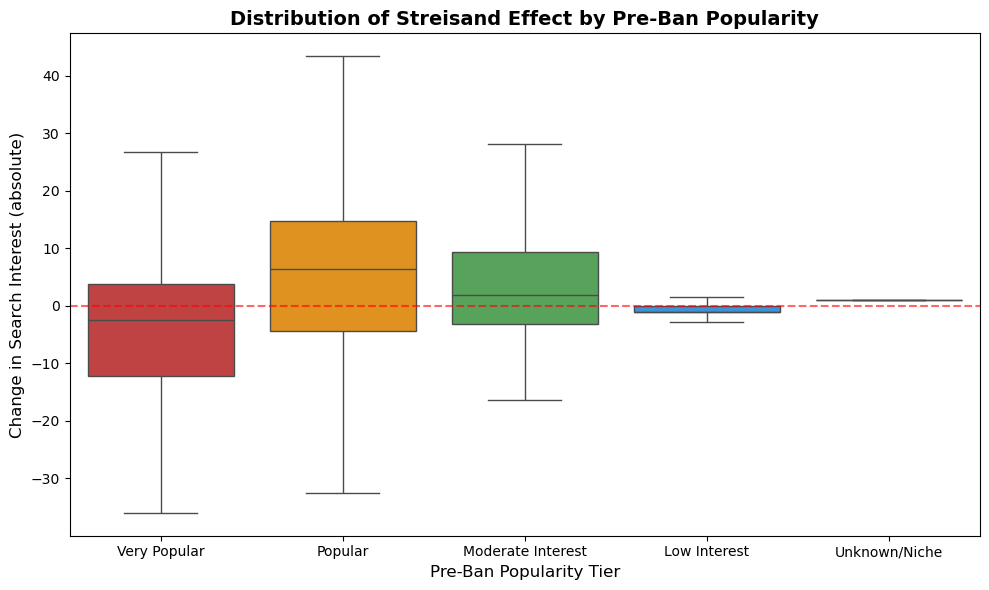

In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

gt = pd.read_csv('outputs/google_trends_cleaned.csv')

# --- Option A: Grouped bar chart (spike rate + mean magnitude) ---

tier_order = ['Very Popular', 'Popular', 'Moderate Interest', 'Low Interest', 'Unknown/Niche']
tier_stats = gt.groupby('pre_ban_popularity').agg(
    spike_rate=('searches_increased', 'mean'),
    mean_spike=('spike_magnitude', 'mean'),
    n=('book_title', 'size')
).reindex(tier_order)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Spike rate bars
x = np.arange(len(tier_order))
colors = ['#d32f2f', '#ff9800', '#4caf50', '#2196f3', '#9e9e9e']
bars = ax1.bar(x, tier_stats['spike_rate'] * 100, width=0.5, color=colors, alpha=0.85)

# Add mean spike as text annotation on each bar
for i, (rate, spike, n) in enumerate(zip(tier_stats['spike_rate'], tier_stats['mean_spike'], tier_stats['n'])):
    ax1.text(i, rate * 100 + 2, f'Δ = {spike:+.1f}\n(n={n})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(tier_order, fontsize=10)
ax1.set_ylabel('% of Books with Increased Search Interest', fontsize=12)
ax1.set_title('The Streisand Effect is Real — But Only for the Right Books', fontsize=14, fontweight='bold')
ax1.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% (coin flip)')
ax1.set_ylim(0, 115)
ax1.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_popularity_tier.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Option B: Box plot (shows full distribution) ---

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=gt, x='pre_ban_popularity', y='spike_magnitude',
            order=tier_order, palette=colors, ax=ax, showfliers=False)
ax.axhline(0, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('Pre-Ban Popularity Tier', fontsize=12)
ax.set_ylabel('Change in Search Interest (absolute)', fontsize=12)
ax.set_title('Distribution of Streisand Effect by Pre-Ban Popularity', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_popularity_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 2: Before/After Scatter Plot

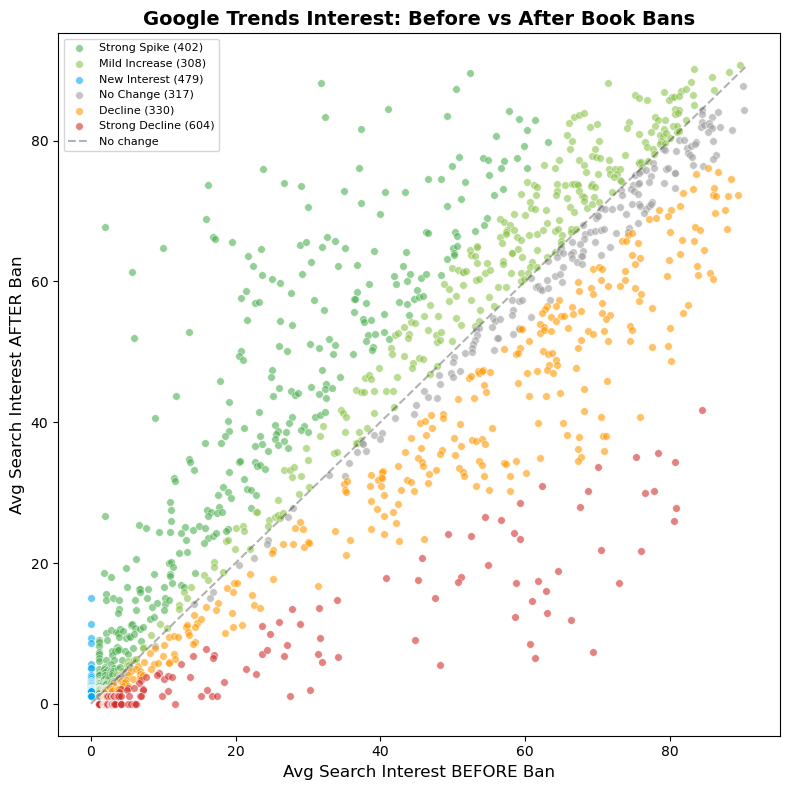

In [9]:
gt = pd.read_csv('outputs/google_trends_cleaned.csv')

fig, ax = plt.subplots(figsize=(8, 8))

# Color by Streisand category
cat_colors = {
    'Strong Spike': '#4caf50',
    'Mild Increase': '#8bc34a',
    'New Interest': '#03a9f4',
    'No Change': '#9e9e9e',
    'Decline': '#ff9800',
    'Strong Decline': '#d32f2f',
}

for cat, color in cat_colors.items():
    subset = gt[gt['streisand_category'] == cat]
    ax.scatter(subset['avg_search_before'], subset['avg_search_after'],
               c=color, label=f'{cat} ({len(subset)})', alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

# Diagonal = no change line
max_val = max(gt['avg_search_before'].max(), gt['avg_search_after'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='No change')

ax.set_xlabel('Avg Search Interest BEFORE Ban', fontsize=12)
ax.set_ylabel('Avg Search Interest AFTER Ban', fontsize=12)
ax.set_title('Google Trends Interest: Before vs After Book Bans', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('viz_before_after_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 3: Top 10 Streisand Effect / Top 10 Suppressed

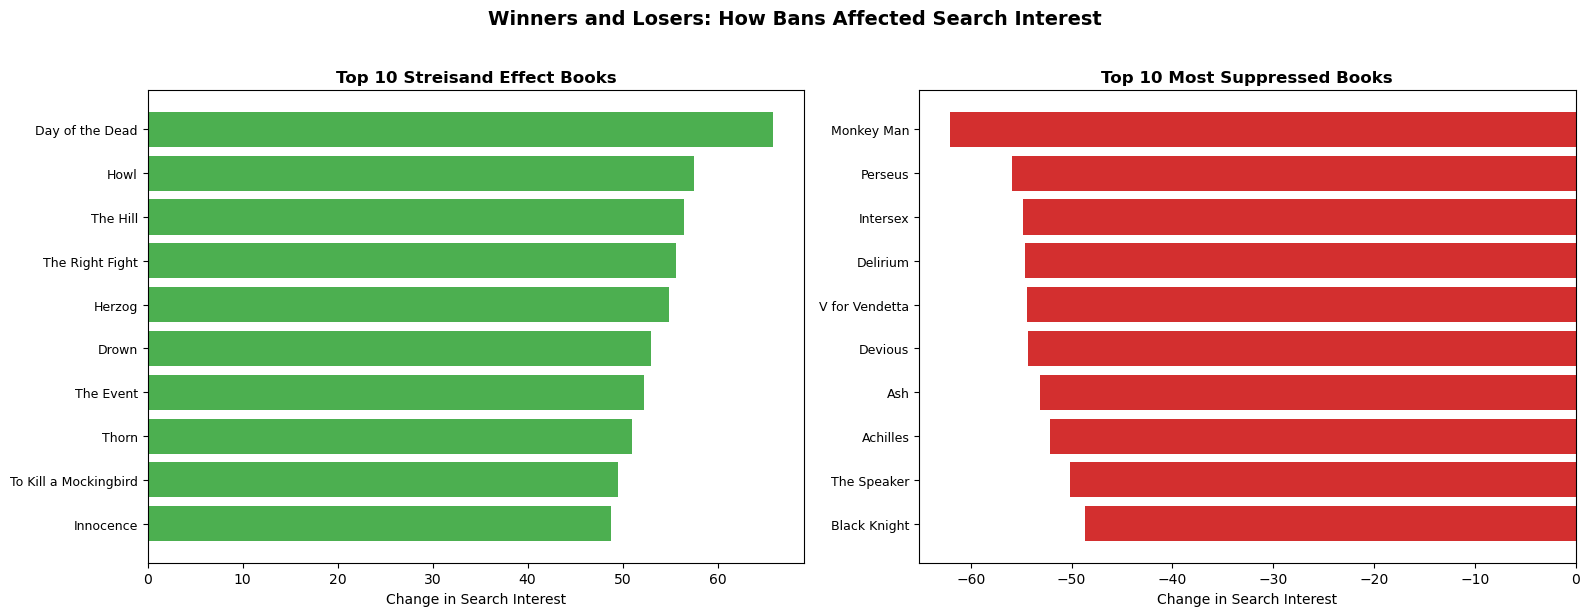

In [10]:
gt = pd.read_csv('outputs/google_trends_cleaned.csv')

# Top 10 biggest spikes (by spike_magnitude)
top_spike = gt.nlargest(10, 'spike_magnitude')[['book_title', 'spike_magnitude', 'avg_search_before', 'avg_search_after']]
# Top 10 biggest declines
top_decline = gt.nsmallest(10, 'spike_magnitude')[['book_title', 'spike_magnitude', 'avg_search_before', 'avg_search_after']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Spike side
ax1.barh(range(len(top_spike)), top_spike['spike_magnitude'], color='#4caf50')
ax1.set_yticks(range(len(top_spike)))
ax1.set_yticklabels([t[:40] for t in top_spike['book_title']], fontsize=9)
ax1.set_xlabel('Change in Search Interest')
ax1.set_title('Top 10 Streisand Effect Books', fontweight='bold')
ax1.invert_yaxis()

# Decline side
ax2.barh(range(len(top_decline)), top_decline['spike_magnitude'], color='#d32f2f')
ax2.set_yticks(range(len(top_decline)))
ax2.set_yticklabels([t[:40] for t in top_decline['book_title']], fontsize=9)
ax2.set_xlabel('Change in Search Interest')
ax2.set_title('Top 10 Most Suppressed Books', fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Winners and Losers: How Bans Affected Search Interest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_top10_both.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 4: Challenge Reason Distribution

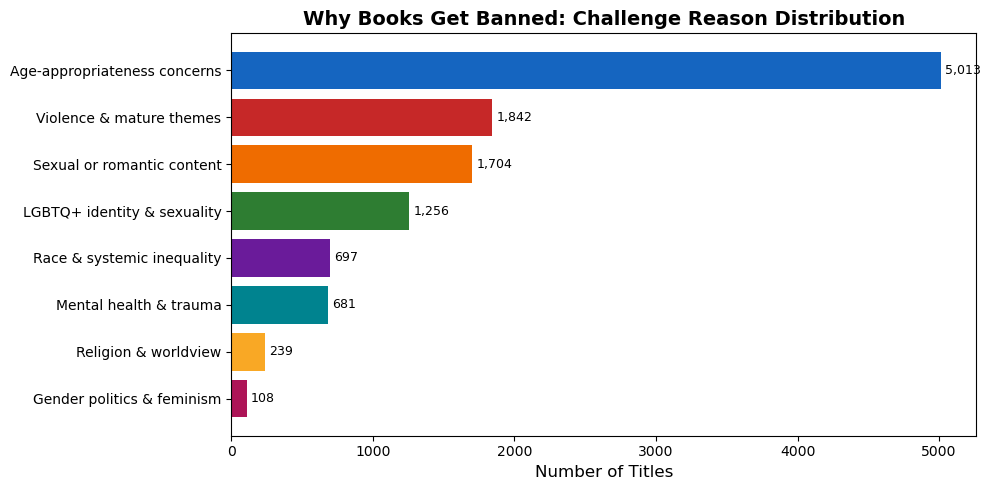

In [11]:
cats = pd.read_csv('outputs/title_categories.csv')

# Explode semicolon-separated reasons
reasons = cats['challenge_reasons'].dropna().str.split('; ').explode()
reasons = reasons[reasons != '']
reason_counts = reasons.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565c0', '#c62828', '#ef6c00', '#2e7d32', '#6a1b9a', '#00838f', '#f9a825', '#ad1457']
bars = ax.barh(range(len(reason_counts)), reason_counts.values, color=colors[:len(reason_counts)])
ax.set_yticks(range(len(reason_counts)))
ax.set_yticklabels(reason_counts.index, fontsize=10)
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_title('Why Books Get Banned: Challenge Reason Distribution', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for i, v in enumerate(reason_counts.values):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_challenge_reasons.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 5: Goodreads Engagement vs Banning

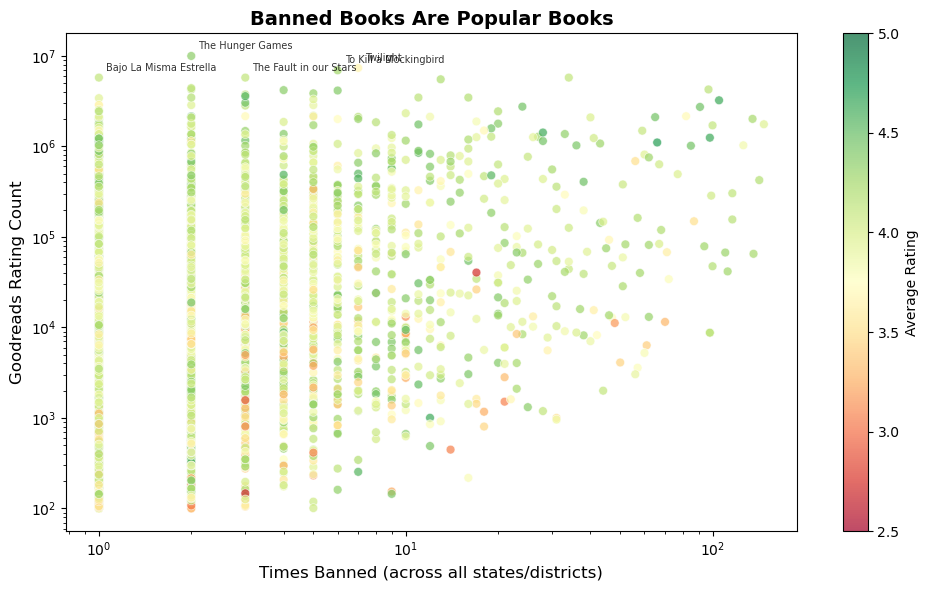

In [12]:

gr = pd.read_csv('outputs/goodreads_cleaned.csv')

# Filter to good quality books with ban data
good = gr[(gr['data_quality'] == 'Good') & (gr['total_ban_instances'].notna())].copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(good['total_ban_instances'], good['rating_count'],
                     c=good['avg_rating'], cmap='RdYlGn', s=40, alpha=0.7,
                     edgecolors='white', linewidth=0.5, vmin=2.5, vmax=5.0)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Times Banned (across all states/districts)', fontsize=12)
ax.set_ylabel('Goodreads Rating Count', fontsize=12)
ax.set_title('Banned Books Are Popular Books', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average Rating', fontsize=10)

# Annotate a few notable books
for _, row in good.nlargest(5, 'rating_count').iterrows():
    ax.annotate(row['book_title'][:25], (row['total_ban_instances'], row['rating_count']),
                fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('viz_goodreads_vs_banning.png', dpi=200, bbox_inches='tight')
plt.show()


## Kevin — Python & Reporting

### Deliverables

1.  Fix election data issue (re-run pipeline)
2.  Methodology section for the final report
3.  Findings narrative
4.  GitHub README + reproducibility docs

### Source Files

-   `analysis_pipeline.py` — the full pipeline
-   `outputs/statistical_results.txt` — all test results
-   All report MDs from prior analysis

### Tutorial Videos

-   Writing a good research methodology: <https://www.youtube.com/watch?v=gkrO1VCfVU4>
-   GitHub README best practices: <https://www.youtube.com/watch?v=E6NO0rgFub4>
-   Python project documentation: <https://www.youtube.com/watch?v=BWIrhJABbas>

### TASK 1: Fix Election Data

In [13]:
# Extract the election xlsx from the zip and place it for the pipeline
import zipfile
import shutil

zip_path = '2024_Presidential_Election_Results.zip'
with zipfile.ZipFile(zip_path) as z:
    for name in z.namelist():
        if 'Results' in name and name.endswith('.xlsx'):
            with z.open(name) as src, open('election_results.xlsx', 'wb') as dst:
                dst.write(src.read())
            print(f'Extracted: {name} → election_results.xlsx')
            break

# Now re-run the pipeline
# python analysis_pipeline.py

FileNotFoundError: [Errno 2] No such file or directory: '2024_Presidential_Election_Results.zip'


### TASK 2: Methodology Section Outline

Write a methodology section covering these topics. Below is the structure with key facts to include:

## Methodology 

### Data Sources
- PEN America Banned Books dataset (22,658 records, 8,360 unique titles, 45 states, 2021-2025)
- Google Trends via pytrends (unofficial API, 3,463 titles collected)
  - 3-month before/after window around each title's earliest ban date
  - US-only, relative interest scale 0-100
  - Rate limited: collected over [X] days with 15-20s delays between calls
- Goodreads (7,293 books scraped, engagement + rating data)
- Census ACS 2023 (state population for per-capita rates)
- 2024 Presidential Election results (county-level, aggregated to state)

### Data Cleaning
- Google Trends: handled inf values (0→>0 = "New Interest"), classified into 6 Streisand categories, computed popularity tiers from pre-ban search volume
- Goodreads: fixed 47 study-guide mismatches using cross-reference with ID lookup file, parsed star distributions from strings to numeric, flagged quality tiers
- Categories: 104 genre keywords mapped to 8 challenge reasons, supplemented with description-based regex keyword matching. Coverage: 80% of titles.

### Statistical Tests
- One-sample t-test: mean percent change ≠ 0
- Kruskal-Wallis + ANOVA: Streisand Effect by challenge reason and by popularity tier
- Mann-Whitney U post-hoc with Bonferroni correction
- Chi-square: spike vs decline rates by category
- Spearman correlation: ban frequency vs spike magnitude
- Effect sizes: Cohen's d, η², Cramér's V


### TASK 3: Findings Narrative Starter

## Key Findings (draft — expand with prose)

### Finding 1: Bans reduce search interest on average
With data on 2,440 books, the mean change in Google Trends interest
after a ban is -6.7%, which is statistically significant (t=-2.39,
p=0.017). Less than half (48.7%) of banned books see increased search
interest. The popular narrative that "banning books always backfires"
is not supported.

### Finding 2: The Streisand Effect is real — but selective
Pre-ban popularity is a highly significant predictor of whether a ban
backfires (H=397.87, p<0.000001, η²=0.116). Books in the "Popular"
tier (20-50 on Google Trends) see a 65% spike rate with a mean increase
of +6.37 points. Books in the "Low Interest" tier see only a 18% spike
rate. Very popular books (50+) actually trend negative (-5.25 mean).

### Finding 3: Content category does not matter
All tests on challenge reason categories return null results (KW p=0.95,
χ² p=0.97). Spike rates range from 44-49% across all 8 categories —
essentially identical. The Streisand Effect is not ideological.

### Finding 4: The ban landscape is highly concentrated
Top 20 districts produce 52.6% of all bans. Iowa's per-capita rate
(118.8/100k) is 3x Florida's (40.3/100k), driven by SF 496 in 2023-24.
The national total peaked at 10,046 in 2023-24 before declining 33%.


### TASK 4: GitHub README Starter

markdown
# Banned But Not Forgotten: The Streisand Effect in Book Censorship

## Overview
Analysis of whether banning books increases public interest, using Google
Trends, Goodreads engagement data, and PEN America's banned books dataset.

## Key Finding
The Streisand Effect is real but selective. Pre-ban popularity — not the
reason for the challenge — determines whether a ban backfires.

## Data
- PEN America banned books dataset (22,658 records, 2021-2025)
- Google Trends interest-over-time (3,463 titles)
- Goodreads engagement (7,293 titles)
- Census ACS 2023, 2024 Presidential Election results

## How to Run

In [14]:
pip install pandas numpy scipy openpyxl
python analysis_pipeline.py

SyntaxError: invalid syntax (2958738072.py, line 1)

All outputs written to `outputs/` folder.

## Repository Structure

```         
├── analysis_pipeline.py          # Full analysis pipeline
├── collect_daily.py              # Google Trends collection script
├── PEN_Combined_21-25_Final.csv  # PEN America data
├── google_trends_raw.csv         # Combined GT collection results
├── goodreads_current.csv         # Goodreads engagement data
├── outputs/
│   ├── google_trends_cleaned.csv
│   ├── goodreads_cleaned.csv
│   ├── title_categories.csv
│   ├── pen_categorized_full.csv
│   ├── state_geographic_analysis.csv
│   ├── categories_x_google_trends.csv
│   ├── master_dataset.csv
│   └── statistical_results.txt
└── visualizations/               # Team-generated charts


## Team

-   Tahvia (PM + Statistical Analysis)
-   Kevin (Google Trends + Reporting)
-   Violet (Goodreads + Visualization)
-   Lauren (Categories + Visualization)
-   Joseph (Geographic Analysis)

---

## Joseph — Data Analysis

### Deliverables
1. Geographic analysis with political data (re-run pipeline after Kevin fixes election file)
2. District concentration analysis
3. Iowa SF 496 case study
4. Time-series by state
5. Streisand Effect by state (now with 2,440 books)

### Source Files
- `outputs/state_geographic_analysis.csv` — 45 states with ban counts, per-capita, political lean
- `outputs/pen_categorized_full.csv` — 22,658 rows with state, district, school year
- `outputs/google_trends_cleaned.csv` — 2,440 rows with state and Streisand data

### Tutorial Videos
- Pandas groupby and aggregation: https://www.youtube.com/watch?v=txMdrV1Ut64
- Folium choropleth maps in Python: https://www.youtube.com/watch?v=4RnU5qKTfYY
- Plotly choropleth for US states: https://www.youtube.com/watch?v=aJmaw3QKMvk
- Time series analysis in Pandas: https://www.youtube.com/watch?v=r0Yrbbkopb4

### TASK 1: District Concentration Analysis

In [15]:
import pandas as pd

pen = pd.read_csv('outputs/pen_categorized_full.csv')

# District-level bans
district_bans = pen.groupby(['State', 'District']).agg(
    total_bans=('Title', 'size'),
    unique_titles=('Title', 'nunique'),
    school_years=('School Year', 'nunique'),
    # What categories are they banning?
    pct_lgbtq=('challenge_reasons', lambda x: x.str.contains('LGBTQ', na=False).mean() * 100),
    pct_sexual=('challenge_reasons', lambda x: x.str.contains('Sexual', na=False).mean() * 100),
    pct_race=('challenge_reasons', lambda x: x.str.contains('Race', na=False).mean() * 100),
).reset_index().sort_values('total_bans', ascending=False)

total = pen.shape[0]

# Concentration stats
print('DISTRICT CONCENTRATION')
for n in [5, 10, 20, 50]:
    top_n_bans = district_bans.head(n)['total_bans'].sum()
    pct = top_n_bans / total * 100
    print(f'  Top {n:2d} districts: {top_n_bans:,d} bans ({pct:.1f}% of all)')

print(f'  Total districts: {len(district_bans)}')

# Top 20 district profiles
print('\nTOP 20 DISTRICTS:')
for _, r in district_bans.head(20).iterrows():
    print(f"  {r['District'][:45]:45s} ({r['State']:12s}): {r['total_bans']:,d} bans, "
          f"{r['unique_titles']} titles, LGBTQ={r['pct_lgbtq']:.0f}%, Sexual={r['pct_sexual']:.0f}%")

# Export
district_bans.to_csv('outputs/district_analysis.csv', index=False)

DISTRICT CONCENTRATION
  Top  5 districts: 5,818 bans (25.7% of all)
  Top 10 districts: 8,553 bans (37.7% of all)
  Top 20 districts: 11,915 bans (52.6% of all)
  Top 50 districts: 16,137 bans (71.2% of all)
  Total districts: 467

TOP 20 DISTRICTS:
  Escambia County Public Schools                (Florida     ): 1,827 bans, 1763 titles, LGBTQ=9%, Sexual=31%
  North East Independent School District        (Texas       ): 1,358 bans, 1334 titles, LGBTQ=27%, Sexual=27%
  Clay County School District                   (Florida     ): 1,259 bans, 1259 titles, LGBTQ=14%, Sexual=30%
  Orange County Public Schools                  (Florida     ): 765 bans, 736 titles, LGBTQ=7%, Sexual=35%
  Hillsborough County Public Schools            (Florida     ): 609 bans, 609 titles, LGBTQ=18%, Sexual=36%
  Department of Defense Educational Activity    (Nation      ): 590 bans, 590 titles, LGBTQ=60%, Sexual=18%
  Katy Independent School District              (Texas       ): 579 bans, 577 titles, LGBTQ=63

### TASK 2: Iowa SF 496 Case Study

In [16]:

import pandas as pd

pen = pd.read_csv('outputs/pen_categorized_full.csv')

iowa = pen[pen['State'] == 'Iowa'].copy()

print(f'Iowa total bans: {len(iowa)}')
print(f'\nBy school year:')
print(iowa.groupby('School Year').size().to_string())

print(f'\nBy ban status:')
print(iowa['Ban Status'].value_counts().to_string())

# Challenge reason profile for Iowa vs national
print('\nIowa challenge reasons vs national:')
for reason in ['LGBTQ', 'Race', 'Sexual', 'Violence', 'Mental', 'Age']:
    iowa_pct = iowa['challenge_reasons'].str.contains(reason, na=False).mean() * 100
    national_pct = pen['challenge_reasons'].str.contains(reason, na=False).mean() * 100
    diff = iowa_pct - national_pct
    print(f'  {reason:12s}: Iowa={iowa_pct:5.1f}%, National={national_pct:5.1f}%, diff={diff:+.1f}%')

# Iowa 2023-24 specifically (the SF 496 year)
iowa_2324 = iowa[iowa['School Year'] == '2023-24']
print(f'\nIowa 2023-24:')
print(f'  Bans: {len(iowa_2324)}')
print(f'  Districts: {iowa_2324["District"].nunique()}')
print(f'  Unique titles: {iowa_2324["Title"].nunique()}')

# Top Iowa districts
print('\nTop 10 Iowa districts:')
iowa_districts = iowa.groupby('District').size().nlargest(10)
for d, n in iowa_districts.items():
    print(f'  {d}: {n}')

Iowa total bans: 3798

By school year:
School Year
2021-22       8
2022-23       6
2023-24    3671
2024-25     113

By ban status:
Ban Status
Banned                                  2295
Banned Pending Investigation            1477
Banned by Restriction                     19
Banned from Libraries and Classrooms       3
Banned from Libraries                      3
Banned from Classrooms                     1

Iowa challenge reasons vs national:
  LGBTQ       : Iowa= 16.0%, National= 20.3%, diff=-4.3%
  Race        : Iowa=  9.0%, National=  8.9%, diff=+0.0%
  Sexual      : Iowa= 42.8%, National= 34.6%, diff=+8.2%
  Violence    : Iowa= 29.9%, National= 26.2%, diff=+3.8%
  Mental      : Iowa= 25.5%, National= 17.1%, diff=+8.5%
  Age         : Iowa= 65.9%, National= 64.5%, diff=+1.5%

Iowa 2023-24:
  Bans: 3671
  Districts: 117
  Unique titles: 1142

Top 10 Iowa districts:
  Nevada Community School District: 242
  Clear Creek-Amana Community School District: 226
  West Burlington Independe


### TASK 3: Time-Series by State

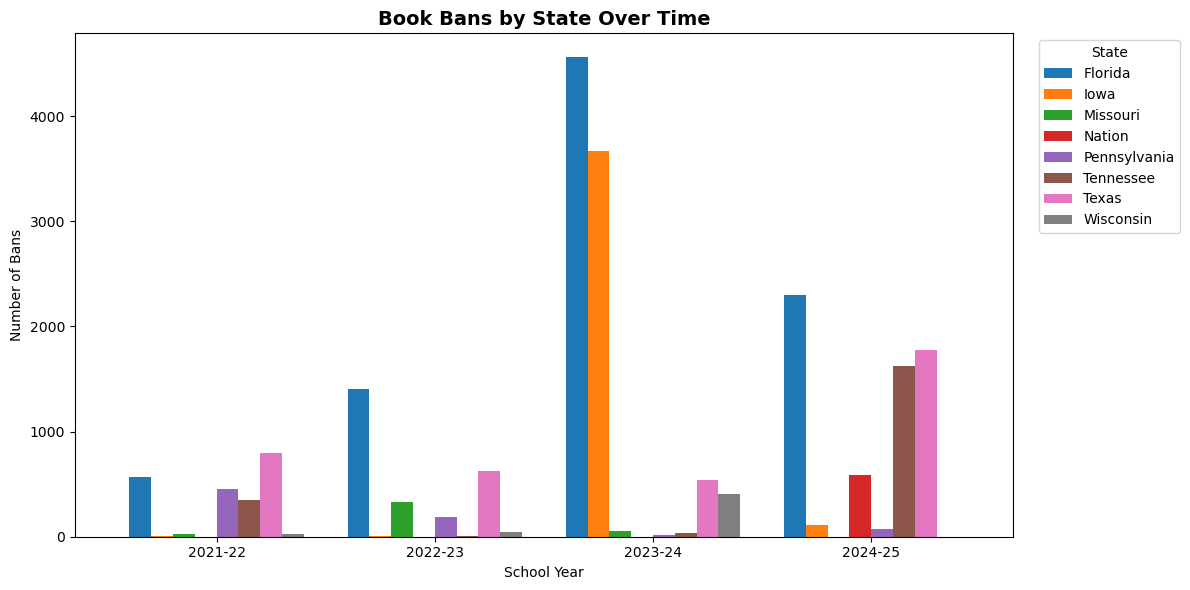


State acceleration (2023-24 → 2024-25):
  Florida             :  4561 →  2304 (-49%)
  Iowa                :  3671 →   113 (-97%)
  Texas               :   538 →  1781 (+231%)
  Tennessee           :    34 →  1622 (+4671%)
  Pennsylvania        :    20 →    73 (+265%)
  Wisconsin           :   408 →     2 (-100%)
  Missouri            :    57 →     2 (-96%)


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

pen = pd.read_csv('outputs/pen_categorized_full.csv')

# Bans by state and school year
state_year = pen.groupby(['State', 'School Year']).size().reset_index(name='bans')

# Pivot for top 8 states
top_states = pen.groupby('State').size().nlargest(8).index.tolist()
pivot = state_year[state_year['State'].isin(top_states)].pivot_table(
    index='School Year', columns='State', values='bans', fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Number of Bans')
ax.set_title('Book Bans by State Over Time', fontsize=14, fontweight='bold')
ax.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_state_time_series.png', dpi=200, bbox_inches='tight')
plt.show()

# Acceleration: which states are growing vs shrinking?
print('\nState acceleration (2023-24 → 2024-25):')
for state in top_states:
    s = state_year[state_year['State'] == state].set_index('School Year')['bans']
    if '2023-24' in s.index and '2024-25' in s.index:
        change = (s['2024-25'] - s['2023-24']) / s['2023-24'] * 100
        print(f'  {state:20s}: {s.get("2023-24", 0):5d} → {s.get("2024-25", 0):5d} ({change:+.0f}%)')

### TASK 4: Streisand Effect by State

In [18]:

import pandas as pd
from scipy import stats

gt = pd.read_csv('outputs/google_trends_cleaned.csv')
state_geo = pd.read_csv('outputs/state_geographic_analysis.csv')

# Check if state column has data
print(f'States in GT data: {gt["state"].nunique()}')
print(f'State value counts:')
print(gt['state'].value_counts().head(15))

# State-level Streisand stats (only states with >= 10 books)
gt_state = gt.groupby('state').agg(
    n_books=('book_title', 'size'),
    mean_spike=('spike_magnitude', 'mean'),
    spike_rate=('searches_increased', 'mean'),
    mean_pct=('percent_change', lambda x: x.replace([float('inf'), float('-inf')], float('nan')).mean())
).reset_index()

gt_state = gt_state[gt_state['n_books'] >= 10].sort_values('mean_spike', ascending=False)
print('\nStreisand Effect by state (≥10 books):')
for _, r in gt_state.iterrows():
    print(f"  {r['state']:20s}: N={r['n_books']:4.0f}, spike rate={r['spike_rate']*100:5.1f}%, mean Δ={r['mean_spike']:+5.2f}")

# Merge with political data for correlation
merged = gt_state.rename(columns={'state': 'state_name'}).merge(
    state_geo[['state_name', 'trump_pct', 'political_lean']], on='state_name', how='left')

valid = merged.dropna(subset=['trump_pct'])
if len(valid) >= 5:
    r, p = stats.spearmanr(valid['trump_pct'], valid['spike_rate'])
    print(f'\nTrump % vs spike rate: ρ={r:.4f}, p={p:.4f} (N={len(valid)})')

# Export
gt_state.to_csv('outputs/streisand_by_state.csv', index=False)

States in GT data: 24
State value counts:
state
Florida         1272
Texas            504
Tennessee        305
Iowa             140
Missouri          66
Wisconsin         38
Pennsylvania      34
Virginia          15
Maine             11
Kentucky          11
Oklahoma           9
Georgia            6
Utah               5
Idaho              4
Michigan           4
Name: count, dtype: int64

Streisand Effect by state (≥10 books):
  Tennessee           : N= 305, spike rate= 51.1%, mean Δ=+1.34
  Missouri            : N=  66, spike rate= 37.9%, mean Δ=+1.22
  Texas               : N= 504, spike rate= 47.4%, mean Δ=+0.28
  Florida             : N=1272, spike rate= 49.6%, mean Δ=+0.05
  Iowa                : N= 140, spike rate= 45.7%, mean Δ=+0.02
  Kentucky            : N=  11, spike rate= 36.4%, mean Δ=-0.01
  Wisconsin           : N=  38, spike rate= 39.5%, mean Δ=-0.64
  Virginia            : N=  15, spike rate= 40.0%, mean Δ=-0.81
  Pennsylvania        : N=  34, spike rate= 55.9%, mean Δ=-

KeyError: "['trump_pct', 'political_lean'] not in index"

## Lauren — Data Visualization & Analysis

### Deliverables

1.  Challenge reason trends over time (line chart)
2.  Choropleth map (bans per capita)
3.  Political overlay choropleth
4.  Ban status breakdown
5.  Year-over-year acceleration chart

### Source Files

-   `outputs/pen_categorized_full.csv` — full PEN with categories
-   `outputs/state_geographic_analysis.csv` — state-level stats
-   `outputs/title_categories.csv` — category data

### Setup

bash
pip install pandas matplotlib seaborn plotly folium numpy


### Tutorial Videos

-   Plotly choropleth maps: <https://www.youtube.com/watch?v=aJmaw3QKMvk>
-   Matplotlib line charts: <https://www.youtube.com/watch?v=UO98lJQ3QGI>
-   Seaborn categorical plots: <https://www.youtube.com/watch?v=6GUZXDef2U0>
-   Folium interactive maps: <https://www.youtube.com/watch?v=4RnU5qKTfYY>

### VIZ 1: Challenge Reason Trends Over Time ⭐

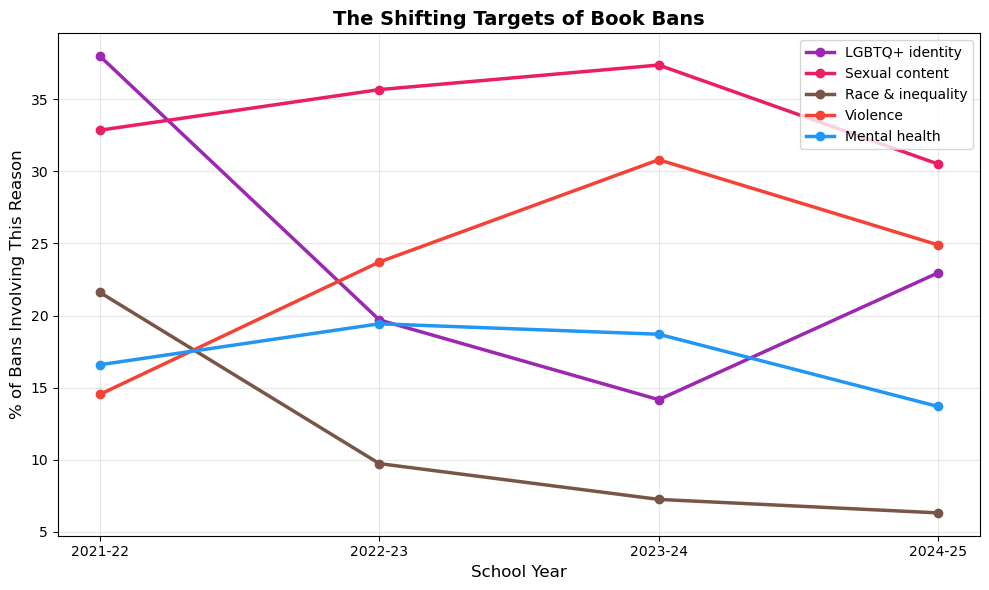

In [19]:

import pandas as pd
import matplotlib.pyplot as plt

pen = pd.read_csv('outputs/pen_categorized_full.csv')

reasons = {
    'LGBTQ+ identity': 'LGBTQ',
    'Sexual content': 'Sexual',
    'Race & inequality': 'Race',
    'Violence': 'Violence',
    'Mental health': 'Mental',
}

years = sorted(pen['School Year'].unique())
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#9c27b0', '#e91e63', '#795548', '#f44336', '#2196f3']
for (label, keyword), color in zip(reasons.items(), colors):
    pcts = []
    for yr in years:
        yr_data = pen[pen['School Year'] == yr]
        pct = yr_data['challenge_reasons'].str.contains(keyword, na=False).mean() * 100
        pcts.append(pct)
    ax.plot(years, pcts, marker='o', linewidth=2.5, label=label, color=color)

ax.set_xlabel('School Year', fontsize=12)
ax.set_ylabel('% of Bans Involving This Reason', fontsize=12)
ax.set_title('The Shifting Targets of Book Bans', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz_reason_trends.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 2: Choropleth Map (Bans Per Capita)

In [20]:

import pandas as pd
import plotly.express as px

states = pd.read_csv('outputs/state_geographic_analysis.csv')

# Need state abbreviations for plotly
state_abbrevs = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

states['abbrev'] = states['state_name'].map(state_abbrevs)
states = states.dropna(subset=['abbrev', 'bans_per_100k'])

fig = px.choropleth(
    states,
    locations='abbrev',
    locationmode='USA-states',
    color='bans_per_100k',
    scope='usa',
    color_continuous_scale='Reds',
    title='Book Bans Per 100,000 Residents by State',
    labels={'bans_per_100k': 'Bans/100k'},
    hover_name='state_name',
    hover_data={'total_bans': True, 'unique_titles_banned': True, 'abbrev': False}
)

fig.update_layout(
    title_font_size=18,
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.write_html('viz_choropleth_percapita.html')
fig.show()


### VIZ 3: Political Overlay Choropleth

In [21]:

import pandas as pd
import plotly.express as px

states = pd.read_csv('outputs/state_geographic_analysis.csv')
# (This requires the pipeline to have been re-run with election data)

state_abbrevs = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

states['abbrev'] = states['state_name'].map(state_abbrevs)
valid = states.dropna(subset=['abbrev', 'bans_per_100k', 'trump_pct'])

# Size = bans per capita, color = political lean
fig = px.choropleth(
    valid,
    locations='abbrev',
    locationmode='USA-states',
    color='trump_pct',
    scope='usa',
    color_continuous_scale='RdBu_r',  # Red=Republican, Blue=Democrat
    range_color=[0.3, 0.7],
    title='Book Bans and Political Lean by State',
    labels={'trump_pct': 'Trump Vote %', 'bans_per_100k': 'Bans/100k'},
    hover_name='state_name',
    hover_data={'total_bans': True, 'bans_per_100k': ':.1f', 'political_lean': True, 'abbrev': False}
)

fig.update_layout(title_font_size=18, margin=dict(l=0, r=0, t=50, b=0))
fig.write_html('viz_choropleth_political.html')
fig.show()

KeyError: ['trump_pct']


### VIZ 4: Ban Status Breakdown

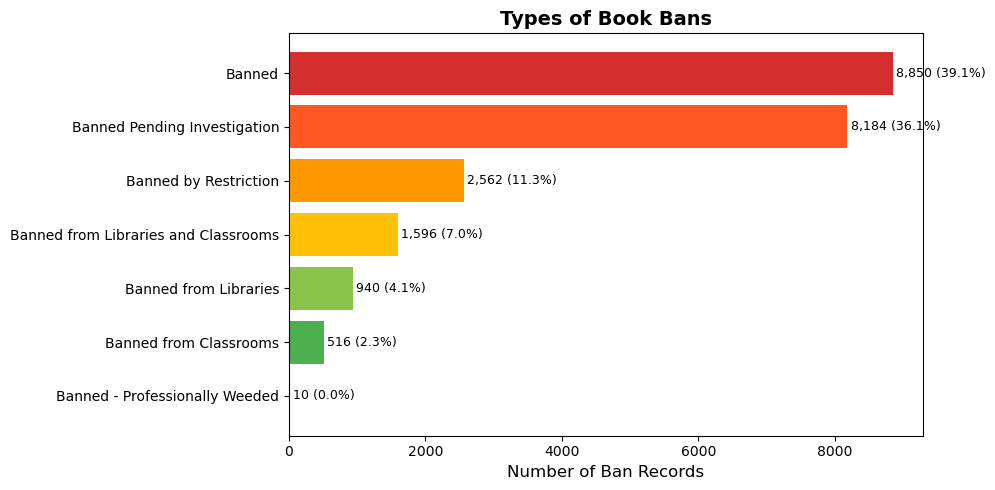

In [22]:

import pandas as pd
import matplotlib.pyplot as plt

pen = pd.read_csv('outputs/pen_categorized_full.csv')

status_counts = pen['Ban Status'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d32f2f', '#ff5722', '#ff9800', '#ffc107', '#8bc34a', '#4caf50', '#9e9e9e']
bars = ax.barh(range(len(status_counts)), status_counts.values, color=colors[:len(status_counts)])
ax.set_yticks(range(len(status_counts)))
ax.set_yticklabels(status_counts.index, fontsize=10)
ax.set_xlabel('Number of Ban Records', fontsize=12)
ax.set_title('Types of Book Bans', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(status_counts.values):
    pct = v / status_counts.sum() * 100
    ax.text(v + 50, i, f'{v:,} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_ban_status.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 5: Year-over-Year Acceleration

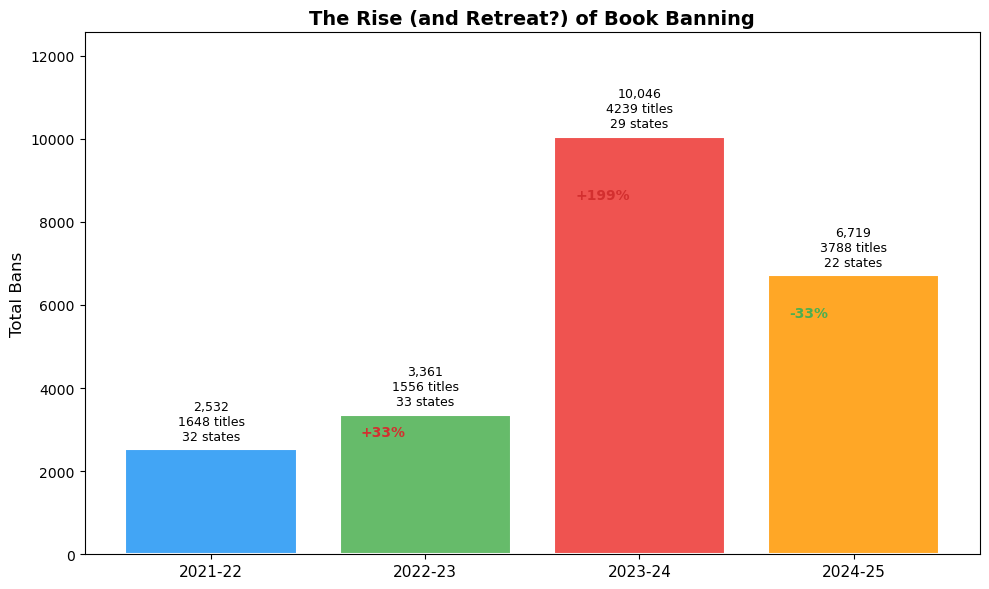

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

pen = pd.read_csv('outputs/pen_categorized_full.csv')

yearly = pen.groupby('School Year').agg(
    bans=('Title', 'size'),
    titles=('Title', 'nunique'),
    states=('State', 'nunique'),
    districts=('District', 'nunique')
).sort_index()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(yearly)), yearly['bans'], color=['#42a5f5', '#66bb6a', '#ef5350', '#ffa726'],
              edgecolor='white', linewidth=1.5)

ax.set_xticks(range(len(yearly)))
ax.set_xticklabels(yearly.index, fontsize=11)
ax.set_ylabel('Total Bans', fontsize=12)
ax.set_title('The Rise (and Retreat?) of Book Banning', fontsize=14, fontweight='bold')

# Annotate with details
for i, (yr, row) in enumerate(yearly.iterrows()):
    ax.text(i, row['bans'] + 150, f"{row['bans']:,}\n{int(row['titles'])} titles\n{int(row['states'])} states",
            ha='center', va='bottom', fontsize=9)

    # YoY arrow
    if i > 0:
        prev = yearly.iloc[i-1]['bans']
        pct = (row['bans'] - prev) / prev * 100
        color = '#4caf50' if pct < 0 else '#d32f2f'
        ax.annotate(f'{pct:+.0f}%', xy=(i, row['bans']),
                    xytext=(i - 0.3, row['bans'] * 0.85),
                    fontsize=10, fontweight='bold', color=color)

ax.set_ylim(0, yearly['bans'].max() * 1.25)
plt.tight_layout()
plt.savefig('viz_yearly_acceleration.png', dpi=200, bbox_inches='tight')
plt.show()